In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import json
import matplotlib as mpl
#mpl.rcParams["font.family"] = "monospace"

from plotting import plot_model_comparison

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
dataset_name = "merfish" # Options: merfish, crc

In [5]:
corr_dir = f"/data/a330d/datasets/{dataset_name}/correlations"
pattern = os.path.join(corr_dir, "*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    core = name[len("crc_"):-len(".json")] if dataset_name == "crc" else name[:-len(".json")]
    parts = core.split("_")
    sid = parts[0]
    model_name = parts[1]
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue

    try:
        rows.append({
            "sid": f"crc_{sid}" if dataset_name == "crc" else sid,
            "model_name": model_name,
            "holdout_celltype": holdout_celltype,
            "n_deg": data.get("n_deg"),
            "spearman": data.get("spearman"),
            "pearson": data.get("pearson"),
            "precision": data.get("precision"),
            "direction_match": data.get("direction_match"),
            "direction_match_k": data.get("direction_match_k"),
            "direction_match_gt": data.get("direction_match_gt"),
            "mixing_index": data.get("mixing_index"),
            "edistance_global": data.get("edistance_global"),
            "edistance_local": data.get("edistance_local"),
            "edistance_pca_log": data.get("edistance_pca_log"),
            "edistance_pca": data.get("edistance_pca"),           
            "rmse": data.get("rmse"),
            "mse_lfc": data.get("mse_lfc"),
        })
    except Exception as e:
        print(f"Error processing file {fp}: {e}")
        continue

data_df = pd.DataFrame(rows)
data_df.head()

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca_log,edistance_pca,rmse,mse_lfc
0,C57BL6J-2.036,baseline-cf,GABAergic neuron_Fiber_tracts,50,0.574783,0.676753,0.00,0.0,0.00,0.08,0.019022,42.347551,43.229744,27.050253,1522.121790,613.618408,398.293091
1,C57BL6J-2.036,baseline-cf,GABAergic neuron_Isocortex,50,0.656297,0.672887,0.20,0.9,0.18,0.60,0.293658,48.110075,52.501921,29.387819,1118.618372,1490.194336,180.199417
2,C57BL6J-2.036,baseline-cf,astrocyte_Fiber_tracts,50,0.301952,0.354013,0.18,1.0,0.18,0.82,0.069700,38.657775,37.840701,17.100988,1407.842004,1868.877075,152.413559
3,C57BL6J-2.036,baseline-cf,astrocyte_Isocortex,50,0.774857,0.715261,0.26,1.0,0.26,0.84,0.000000,64.602134,66.657219,36.885138,2111.273730,2971.760254,154.598236
4,C57BL6J-2.036,baseline-cf,endothelial cell_Fiber_tracts,50,0.742315,0.662692,0.06,1.0,0.06,0.86,0.003236,43.568983,43.794907,21.782019,1866.005750,1668.539429,96.198738


In [6]:
# Remove -cf from the end of each model_name
data_df["model_name"] = data_df["model_name"].str.replace("-cf", "", regex=False)
n_deg = data_df["n_deg"].iloc[0]
data_df.head()

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca_log,edistance_pca,rmse,mse_lfc
0,C57BL6J-2.036,baseline,GABAergic neuron_Fiber_tracts,50,0.574783,0.676753,0.00,0.0,0.00,0.08,0.019022,42.347551,43.229744,27.050253,1522.121790,613.618408,398.293091
1,C57BL6J-2.036,baseline,GABAergic neuron_Isocortex,50,0.656297,0.672887,0.20,0.9,0.18,0.60,0.293658,48.110075,52.501921,29.387819,1118.618372,1490.194336,180.199417
2,C57BL6J-2.036,baseline,astrocyte_Fiber_tracts,50,0.301952,0.354013,0.18,1.0,0.18,0.82,0.069700,38.657775,37.840701,17.100988,1407.842004,1868.877075,152.413559
3,C57BL6J-2.036,baseline,astrocyte_Isocortex,50,0.774857,0.715261,0.26,1.0,0.26,0.84,0.000000,64.602134,66.657219,36.885138,2111.273730,2971.760254,154.598236
4,C57BL6J-2.036,baseline,endothelial cell_Fiber_tracts,50,0.742315,0.662692,0.06,1.0,0.06,0.86,0.003236,43.568983,43.794907,21.782019,1866.005750,1668.539429,96.198738


In [7]:
df = data_df.copy() # start with existing dataframe
df["sid"] = df["sid"].astype(str)

In [8]:
def unify_formatting(df_parent, df_child):
    df_child["holdout_celltype"] = df_child["holdout_celltype"] + "_" + df_child["target_domain"]
    df_child["sid"] = df_child["sid"].astype(str)

    common_cols = df_parent.columns
    df_child_trimmed = df_child[common_cols.intersection(df_child.columns)]
    combined = pd.concat([df_parent, df_child_trimmed], axis=0, ignore_index=True)

    return combined

In [9]:
# Load mintflow results
mintflow_base_path = f"../results/mintflow_{dataset_name}"
mintflow_df = pd.DataFrame()

# Loop over mintflow_base_path and read each file, concatenate into mintflow_df
for file in glob.glob(f"{mintflow_base_path}/mintflow_*.csv"):
    temp_df = pd.read_csv(file)
    mintflow_df = pd.concat([mintflow_df, temp_df], ignore_index=True)
    mintflow_df = mintflow_df[mintflow_df["n_deg"] == n_deg]
mintflow_df.head()

,dataset_name,sid,control_domain,target_domain,n_deg,model_name,holdout_celltype,spearman,pearson,precision,direction_match,direction_match_k,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca_log,edistance_pca,rmse,mse_lfc
0,merfish,C57BL6J-2.039,Thalamus,Isocortex,50,mintflow,glutamatergic neuron,0.848932,0.974533,0.40,1.0,0.40,0.98,0.036611,56.996777,56.553260,18.989016,709.207642,28306.2540,7.530582
1,merfish,C57BL6J-2.039,Thalamus,Fiber_tracts,50,mintflow,glutamatergic neuron,0.555054,0.883090,0.42,1.0,0.42,1.00,0.900800,56.920282,58.850383,18.296927,834.091986,2032.4878,3.092700
2,merfish,C57BL6J-2.039,Thalamus,Isocortex,50,mintflow,oligodendrocyte,0.558992,0.566383,0.28,1.0,0.28,0.48,0.108280,69.530568,68.301408,18.730404,2019.832422,2505.9507,122.524490
3,merfish,C57BL6J-2.039,Thalamus,Fiber_tracts,50,mintflow,oligodendrocyte,0.410132,0.751570,0.02,1.0,0.02,0.28,0.047658,77.646770,77.061536,22.748677,3088.707544,11150.9720,25.893583
4,merfish,C57BL6J-2.039,Thalamus,Isocortex,50,mintflow,astrocyte,0.776423,0.830059,0.22,1.0,0.22,0.82,0.061776,68.142665,66.710427,22.549525,1660.681067,5132.9277,17.714468


In [10]:
combined_df = unify_formatting(df, mintflow_df)

In [11]:
spprop_csv_path = f'../results/loo_spatialprop_{dataset_name}_DEG_{int(n_deg)}.csv'
spprop_df = pd.read_csv(spprop_csv_path)
spprop_df.head()

,dataset_name,sid,control_domain,target_domain,n_deg,model_name,holdout_celltype,spearman,pearson,precision,...,direction_match_k,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca_log,edistance_pca,rmse,mse_lfc,top_n_perturb
0,merfish,C57BL6J-2.036,Thalamus,Isocortex,50,spatialprop,glutamatergic neuron,0.673758,0.764713,0.00,...,0.00,0.90,0.019952,51.808403,63.381221,32.313984,520.414062,20746.24600,15.853912,1120
1,merfish,C57BL6J-2.036,Thalamus,Fiber_tracts,50,spatialprop,glutamatergic neuron,0.508283,0.463431,0.00,...,0.00,0.78,0.201313,43.186705,59.320327,22.488812,354.981882,1177.27770,23.126091,1120
2,merfish,C57BL6J-2.036,Thalamus,Isocortex,50,spatialprop,GABAergic neuron,0.719280,0.779942,0.02,...,0.02,0.82,0.999131,46.919764,57.429229,19.851588,322.772464,2933.00880,75.309960,1120
3,merfish,C57BL6J-2.036,Thalamus,Fiber_tracts,50,spatialprop,GABAergic neuron,0.736759,0.781587,0.08,...,0.08,0.82,0.633152,39.432160,51.769618,16.134004,289.410464,945.50684,54.038383,1120
4,merfish,C57BL6J-2.036,Thalamus,Isocortex,50,spatialprop,astrocyte,0.740120,0.777023,0.08,...,0.08,0.88,0.020351,54.499195,61.636049,21.259093,496.693753,4260.46300,23.080711,1120


In [12]:
combined_df = unify_formatting(combined_df, spprop_df)

In [46]:
# Add node-perturbation results
cellina_pert_df = pd.read_csv(f"../results/loo_cellina_{dataset_name}_DEG_{int(n_deg)}_pert.csv")
spprop_pert_df = pd.read_csv(f"../results/loo_spatialprop_{dataset_name}_DEG_{int(n_deg)}_pert.csv")
spprop_pert_df['model_name'] += "-pert"

In [47]:
combined_df = unify_formatting(combined_df, cellina_pert_df)
combined_df = unify_formatting(combined_df, spprop_pert_df)

In [13]:
combined_df.to_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}.csv", index=False)

In [ ]:
combined_df["model_name"] = combined_df["model_name"].replace("cellina-graph", "cellina-gat")
combined_df = combined_df.rename(columns={"direction_match_k": "signed_precision"})
combined_df = combined_df.rename(columns={"edistance_pca_log": "e-distance"})

In [16]:
grouping = "holdout_celltype"

# Define order
model_order = [
    "baseline",
    "cpa",
    "scgen",
    "mintflow",
    "spatialprop",
    "cellina-ablated",
    "cellina",
    "cellina-gat",
    "spatialprop-pert",
    "cellina-pert",
    "cellina-gat-pert",
]

default_palette = 'colorblind'
palette = default_palette

In [17]:
palette_dict = {
    'cellina': '#8172B2',
    'cellina-pert': '#8172B2',
    'cellina-ablated': "#BCB8C9",
    'cellina-gat': "#573BB1",
    'cellina-gat-pert': "#573BB1",
    'scgen':   'orange',
    'cpa':     "#8A5816",
    'mintflow':    'green',
    'spatialprop': 'skyblue',
    'spatialprop-pert': 'skyblue',
    'baseline':  'red',
}
palette = palette_dict

In [19]:
combined_df["holdout_celltype"] = combined_df["holdout_celltype"].str.replace("Fiber_tracts", "Fiber-tracts", regex=False)
combined_df["perturbation"] = combined_df["holdout_celltype"].apply(lambda x: "".join(x.split("_")[-1]) if len(x.split("_")) > 1 else "")
combined_df["holdout_celltype"] = combined_df["holdout_celltype"].apply(lambda x: "-".join(x.split("_")[:-1]))

In [20]:
combined_df_1 = combined_df[combined_df["perturbation"].str.contains("Isocortex")]
combined_df_2 = combined_df[combined_df["perturbation"].str.contains("Fiber-tracts")]

In [21]:
from matplotlib.patches import Patch

def plot_model_comparison(
    dataset_name,
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_path="../figures",
    save_name="ood_summary",
    hide=False,
    legend_only=False
):
    hatch_map = {
    "cellina-pert": "///",
    "cellina-gat-pert": "///",
    "spatialprop-pert": "///"
    }

    if legend_only:
        fig = plt.figure(figsize=(6, 1))
        handles = [
            Patch(
                facecolor=palette[m],
                edgecolor="black" if m in hatch_map else "none",
                hatch=hatch_map[m] if m in hatch_map else "",
                label=m
            )
            for m in model_order
        ]
        fig.legend(handles, model_order, ncol=len(model_order), loc="center", fontsize=16)
        plt.axis("off")
        if save:
            plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches="tight")
        plt.show()
        return
    
    # Compute global y-limits
    ymin = df[metrics].min().min() * 0.3
    ymax = df[metrics].max().max() * 1.05

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
    n_deg = df["n_deg"].iloc[0]    

    title = f"{dataset_name}: Performance for DEG {n_deg} (Thalamus → {df.perturbation.unique()[0]})"
    if hide:
        title = ""
    fig.suptitle(title, fontsize=20)

    # Ensure axes iterable if only one metric
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        if not average_only:
            # -------------------------------
            # Per-celltype plot
            # -------------------------------
            celltypes = df[grouping].unique().tolist()
            all_x_labels = list(celltypes)

            ymin = df[metric].min().min() * 0.3
            ymax = df[metric].max().max() * 1.05

            sns.barplot(
                data=df,
                x=grouping,
                y=metric,
                hue="model_name",
                estimator="mean",
                errorbar="se",
                hue_order=model_order,
                ax=ax,
                palette=palette,
                order=celltypes,
                dodge=True,
                width=.85,
            )

            for container, model in zip(ax.containers, model_order):
                if model in hatch_map:
                    for bar in container:
                        bar.set_hatch(hatch_map[model])
                        bar.set_linewidth(1.0)
            
            ax.legend_.remove()

            

            for container, model in zip(ax.containers, model_order):
                for bar in container:
                    
                    # always light grey border for base bars
                    bar.set_edgecolor("lightgrey")
                    bar.set_linewidth(0.8)

                    # if hatch model → overlay a hatch-only bar
                    if model in hatch_map:
                        ax.add_patch(
                            plt.Rectangle(
                                (bar.get_x(), bar.get_y()),
                                bar.get_width(),
                                bar.get_height(),
                                fill=False,
                                hatch=hatch_map[model],
                                edgecolor="black",   # hatch color
                                linewidth=0
                            )
                        )

            ax.set_xticks(range(len(all_x_labels)))
            ax.set_xticklabels(all_x_labels, rotation=45)
            ax.tick_params(axis="y", labelsize=15)
            ax.tick_params(axis="x", labelsize=15)
            ax.set_ylim(ymin, ymax)
        

        else:
            # -------------------------------
            # AVERAGE-ONLY plot (clean)
            # -------------------------------
            df_avg = (
                df.groupby(["model_name"])[metric]
                .agg(["mean", "sem"])
                .reset_index()
            )

            sns.barplot(
                data=df_avg,
                x="model_name",
                y="mean",
                hue="model_name",
                order=model_order,
                palette=palette,
                errorbar=None,  # we add manually
                ax=ax,
            )

            # Add SE manually
            for i, model in enumerate(model_order):
                row = df_avg[df_avg.model_name == model].iloc[0]
                ax.errorbar(
                    x=i,
                    y=row["mean"],
                    yerr=row["sem"],
                    fmt="none",
                    capsize=0,
                    color="black",
                )

            #ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
            ax.tick_params(axis="x", rotation=45)

        # -------------------------------
        # Shared styling
        # -------------------------------
        
        ax.set_title(metric, fontsize=18)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # -------------------------------
    # Global legend (only once)
    # -------------------------------
    if not average_only:
        handles, labels = axes[0].get_legend_handles_labels()
    else:
        handles = [
            plt.Rectangle((0, 0), 1, 1, color=palette[m])
            for m in model_order
        ]
        labels = model_order

    #if hide:
    # Set legend visible False
    handles = []
    labels = []
    
    """
    fig.legend(
    handles,
    labels,
    ncol=1,                 # vertical
    fontsize=16,
    loc="center left",      # align legend box
    bbox_to_anchor=(1.02, 0.5),  # move to the right
    )
    """
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)

    if save:
        plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches="tight")
    plt.show()

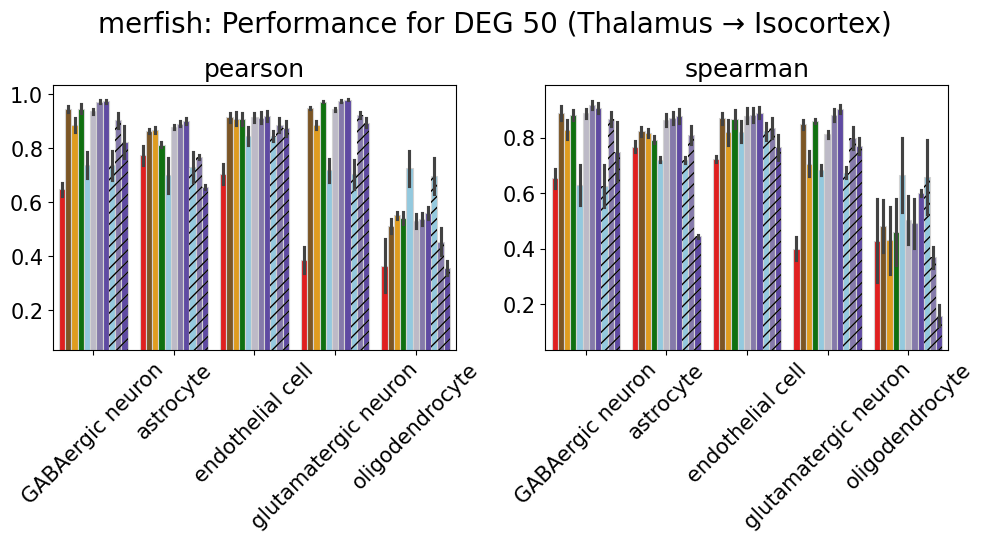

In [22]:
metrics = ["pearson", "spearman"]
plot_model_comparison(
    dataset_name,
    combined_df_1,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Isocortex_1",
    hide=False
)

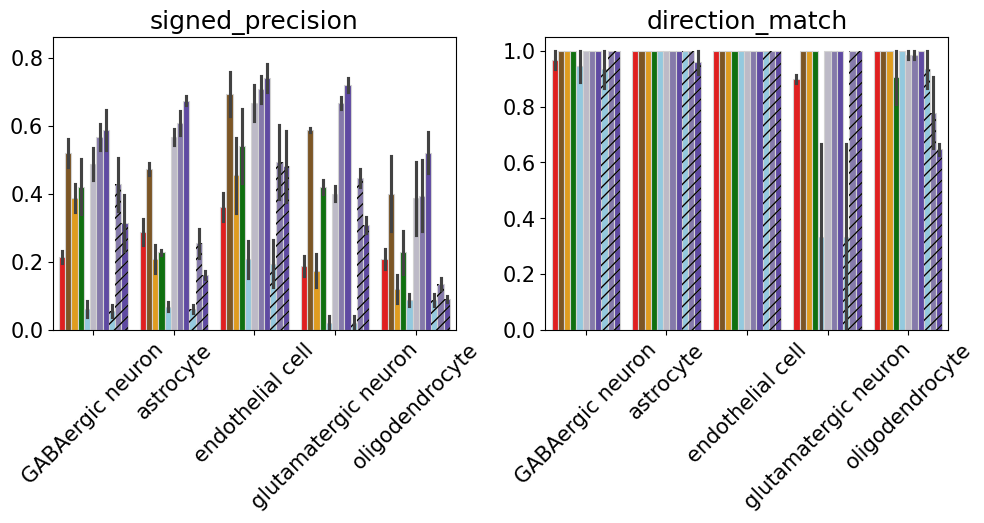

In [23]:
metrics = ["signed_precision", "direction_match"]
plot_model_comparison(
    dataset_name,
    combined_df_1,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Isocortex_2",
    hide=True
)

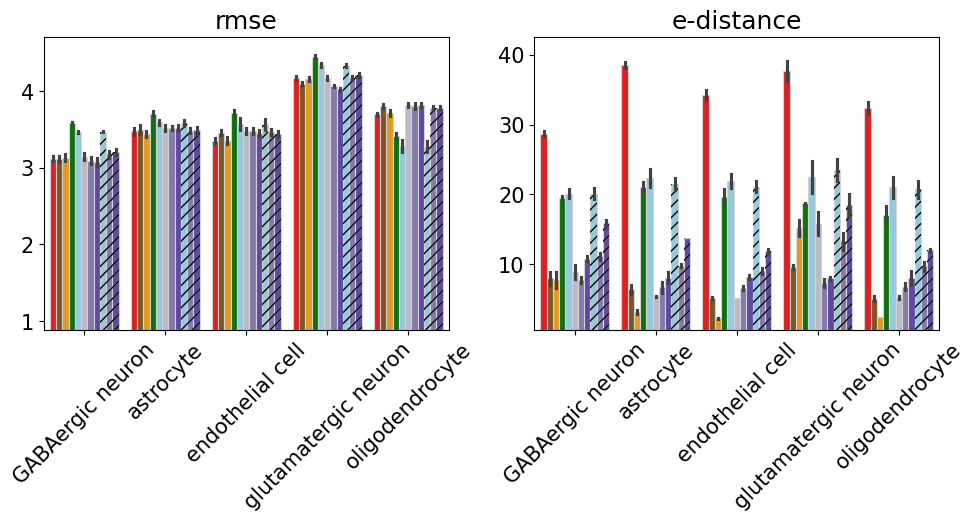

In [24]:
metrics = ["rmse", "e-distance"]
plot_model_comparison(
    dataset_name,
    combined_df_1,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Isocortex_3",
    hide=True
)

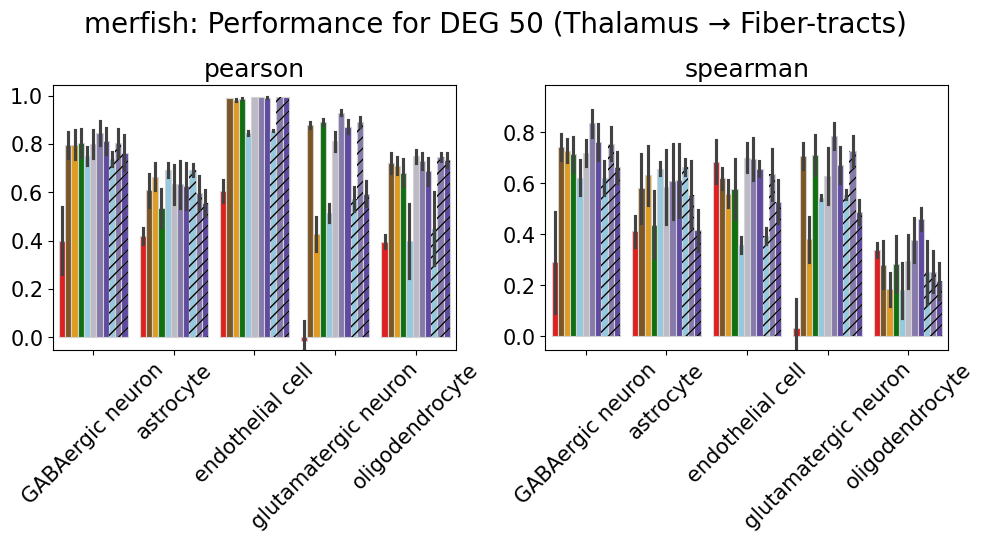

In [25]:
metrics = ["pearson", "spearman"]
plot_model_comparison(
    dataset_name,
    combined_df_2,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Fiber-tracts_1",
    hide=False
)

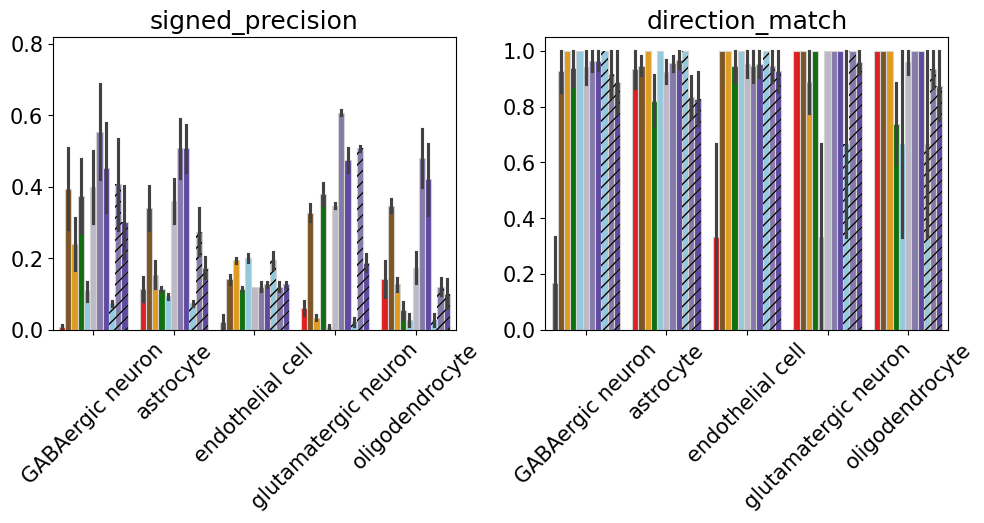

In [26]:
metrics = ["signed_precision", "direction_match"]
plot_model_comparison(
    dataset_name,
    combined_df_2,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Fiber-tracts_2",
    hide=True
)

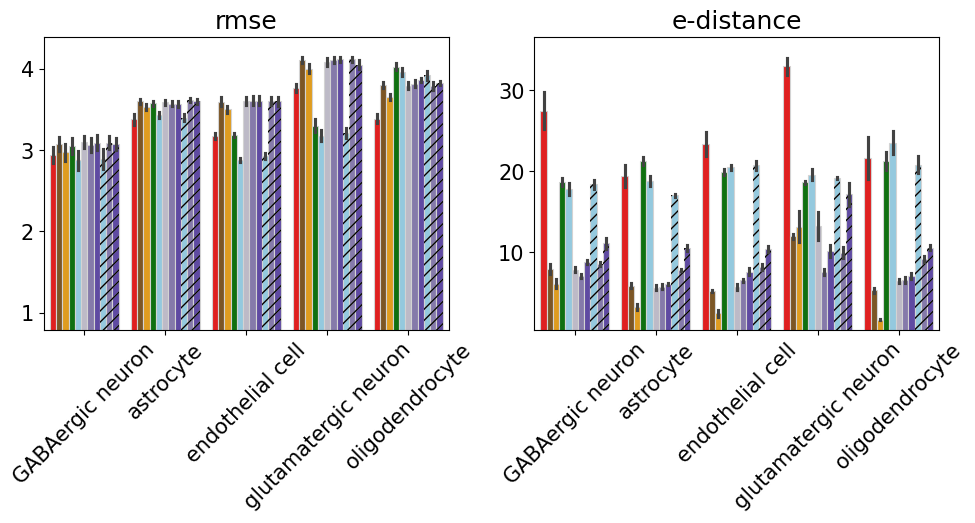

In [27]:
metrics = ["rmse", "e-distance"]
plot_model_comparison(
    dataset_name,
    combined_df_2,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name=f"{dataset_name}_{n_deg}_bars_Fiber-tracts_3",
    hide=True
)

In [34]:
combined_df.isna().sum()

sid                   0
model_name            0
holdout_celltype      0
n_deg                 0
spearman              0
pearson               0
precision             0
direction_match       0
direction_match_k     0
direction_match_gt    0
mixing_index          0
edistance_global      0
edistance_local       0
edistance_pca_log     0
edistance_pca         0
rmse                  0
dtype: int64

## Add average rank column

In [28]:
metrics = [
    "pearson",
    #"spearman",
    "precision",
    #"direction_match",
    #"rmse",
    "edistance_local",
]

direction = {
    "pearson": "higher",
    #"spearman": "higher",
    "precision": "higher",
    #"direction_match": "higher",
    #"rmse": "lower",
    "edistance_local": "lower",
}

In [ ]:
df_ranked = combined_df.copy()

# compute ranks only temporarily
rank_cols = []
group_cols = ["sid", "holdout_celltype"]

for m in metrics:
    ascending = direction[m] == "lower"

    rank_col = f"{m}_rank"
    df_ranked[rank_col] = (
        df_ranked.groupby(group_cols)[m]
        .rank(ascending=ascending, method="average")
    )
    rank_cols.append(rank_col)

# final aggregate rank
df_ranked["avg_rank"] = df_ranked[rank_cols].mean(axis=1)

# drop intermediate rank columns
df_ranked = df_ranked.drop(columns=rank_cols)

In [ ]:
df_ranked

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse,avg_rank
0,crc_120,baseline,Endothelial_CRC,50,0.548619,0.497170,0.10,1.000000,0.10,0.547060,13.249699,15.278936,5856.333946,6.500000
1,crc_120,baseline,Epithelial_CRC,50,0.442017,0.330887,0.26,0.769231,0.20,0.895650,9.924456,8.871777,652016.069078,5.666667
2,crc_120,baseline,Fibroblast_CRC,50,0.378247,0.385970,0.16,1.000000,0.16,0.605086,8.445271,10.781323,180004.851410,5.000000
3,crc_120,baseline,Myeloid_CRC,50,0.510492,0.456200,0.14,1.000000,0.14,0.502754,14.798410,16.269466,36416.168085,5.666667
4,crc_120,baseline,T_cell_CRC,50,0.836351,0.712031,0.12,1.000000,0.12,0.797638,16.806622,18.496396,22608.232002,5.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,crc_120,spatialprop,Endothelial_CRC,50,0.563505,0.499551,0.04,1.000000,0.04,0.812261,6.878066,9.875358,43287.758000,6.333333
226,crc_120,spatialprop,Epithelial_CRC,50,0.663481,0.607788,0.04,1.000000,0.04,0.779179,6.894642,7.006116,501439.750000,6.333333
227,crc_120,spatialprop,Fibroblast_CRC,50,0.049412,-0.074937,0.06,0.333333,0.02,0.693359,5.286521,8.863244,229567.550000,5.833333
228,crc_120,spatialprop,Myeloid_CRC,50,0.397839,0.450173,0.04,1.000000,0.04,0.744805,10.499007,13.860851,120845.555000,6.000000


In [36]:
df_ranked.to_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}_ranked.csv", index=False)